<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Práctico Final: MLOps Local con Monitoreo de Data Drift
## Fase 2 — Modelado sin Fuga de Datos
### Magíster en Ciencia de Datos — Tópicos en Data Science II
---

**Integrantes:** Gerardo Galán - Mabel Herrera

**Continúa de:** `practico_06_proyecto_final_f0_f1_eda_Gerardo_Galan_Mabel_Herrera.ipynb` (Fases 0-1)

---

## Objetivo de esta fase (RAA3)

1. Construir **features de rezago (*lag features*) seguras** (sin fuga temporal), aplicando la tabla de mitigaciones definida en la Fase 1.
2. Definir una **arquitectura de validación temporal robusta** (`TimeSeriesSplit`), y **demostrar cuantitativamente** — igual que en el Práctico 5 con `duration` — cuánto se infla la métrica si en su lugar se usa validación cruzada aleatoria.
3. Comparar modelos y elegir uno, con métricas **reportadas por ciudad** (no solo agregadas, por el hallazgo de la Fase 1 sobre la diferencia de escala entre SJ e IQ).
4. Reservar un conjunto de **"producción simulada"** (datos reales más recientes, nunca vistos en entrenamiento) para usar en la Fase 4.
5. Empaquetar el pipeline completo de forma **reproducible** con `joblib`, listo para que la Fase 3 (servicio de inferencia) lo cargue directamente.


---
## 🔧 Bootstrap para Google Colab

Esta celda trae el proyecto completo (código en `src/`, `service/`, datos y modelo ya entrenado) al entorno de Colab, que empieza vacío en cada sesión. Si `REPO_URL` está vacío, la celda ofrece subir un `.zip` del repositorio en su lugar.

**No hace falta editar nada más de este notebook** — el resto de las celdas ya usan rutas relativas (`../data/`, `../models/`, etc.) que funcionan igual aquí que en una máquina local, una vez que el directorio de trabajo queda en `notebooks/`.


In [ ]:
# ── Bootstrap para Google Colab: trae el repositorio a este entorno ──
import os

REPO_URL = ""  # <-- si suben el proyecto a GitHub, peguen aqui la URL (ej. "https://github.com/usuario/dengue_mlops_drift_repo_1.git")
REPO_DIR = "/content/dengue_mlops_drift_repo_1"

IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

if IN_COLAB and not os.path.exists(REPO_DIR):
    if REPO_URL:
        print("Clonando repositorio...")
        get_ipython().system('git clone -q "{}" "{}"'.format(REPO_URL, REPO_DIR))
    else:
        print("REPO_URL esta vacio. Selecciona el .zip del repositorio para subirlo:")
        from google.colab import files
        subido = files.upload()
        zip_name = list(subido.keys())[0]
        os.makedirs(REPO_DIR, exist_ok=True)
        get_ipython().system('unzip -q "{}" -d "{}"'.format(zip_name, REPO_DIR))
        contenido = os.listdir(REPO_DIR)
        if len(contenido) == 1 and os.path.isdir(os.path.join(REPO_DIR, contenido[0])):
            sub = os.path.join(REPO_DIR, contenido[0])
            for item in os.listdir(sub):
                os.rename(os.path.join(sub, item), os.path.join(REPO_DIR, item))
            os.rmdir(sub)

if IN_COLAB:
    os.chdir(os.path.join(REPO_DIR, "notebooks"))
    print("Directorio de trabajo:", os.getcwd())
else:
    print("No se detecto Colab -- se asume ejecucion local normal, sin cambios de directorio.")


---
## Setup

Reutilizamos dos módulos que dejamos en `src/` para que el resto de las fases (servicio de inferencia, monitoreo de drift) puedan importar exactamente la misma lógica de carga y de features — si cada fase reimplementara su propia versión, correríamos el riesgo de que el pipeline de producción calcule las features distinto a como se entrenó el modelo, que es en sí mismo otra forma de fuga/inconsistencia.

- `src/data.py` → `cargar_datos_dengue()`, `split_referencia_produccion()`
- `src/features.py` → `construir_lag_features()`, `verificar_sin_fuga_temporal()`, `preparar_dataset_modelado()`


In [1]:
# ── Importaciones ──
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.data import cargar_datos_dengue, split_referencia_produccion
from src.features import preparar_dataset_modelado, FEATURES_CLIMATICAS, LAGS_SEMANAS

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42
DATA_DIR = '../data/raw/'

print("Librerías cargadas")


Librerías cargadas


In [2]:
# ── Carga de datos (mismo dataset maestro que en Fase 1) ──
df, feat_test, sub_format = cargar_datos_dengue(DATA_DIR)
print(f"df: {df.shape}  |  rango: {df['week_start_date'].min().date()} .. {df['week_start_date'].max().date()}")
df[['city','year','weekofyear','week_start_date','total_cases']].head()


df: (1456, 25)  |  rango: 1990-04-30 .. 2010-06-25


,city,year,weekofyear,week_start_date,total_cases
0,iq,2000,26,2000-07-01,0
1,iq,2000,27,2000-07-08,0
2,iq,2000,28,2000-07-15,0
3,iq,2000,29,2000-07-22,0
4,iq,2000,30,2000-07-29,0


---
## Paso 1 — Split temporal: Referencia (entrenamiento) vs. Producción simulada

### Teoría: por qué esto no es "solo" un train/test split

En un problema tabular sin estructura temporal, un `train_test_split` aleatorio bastaría. Acá tenemos que decidir **dos cosas a la vez**: cómo entrenar/validar el modelo (Fase 2) y qué datos reservar para simular la llegada de "producción" en la Fase 4. La decisión de diseño es reservar el **20% más reciente de cada ciudad** como *producción simulada*: son datos reales, con etiquetas verdaderas, pero el modelo **nunca los ve durante el entrenamiento ni la validación**. Esto evita dos errores comunes:

- Usar el archivo `dengue_features_test.csv` del enunciado original de Kaggle para esto — ese archivo **no tiene labels** (es el que se usaría para un submission a la competencia), así que no serviría para medir el desempeño real del modelo en la Fase 4.
- Simular el drift de forma artificial (perturbando features a mano) cuando el propio dataset ya tiene un eje temporal real que lo permite — igual que decidimos en la Fase 0 al elegir este caso sobre, por ejemplo, Bank Marketing.


In [3]:
# ── Split temporal por ciudad (80% referencia / 20% producción simulada) ──
df_ref, df_prod = split_referencia_produccion(df, frac_referencia=0.8)

resumen_split = pd.DataFrame({
    'conjunto': ['Referencia (train/val Fase 2)', 'Producción simulada (Fase 4)'],
    'filas': [len(df_ref), len(df_prod)],
}).assign(**{
    'sj (fechas)': [
        f"{df_ref[df_ref.city=='sj']['week_start_date'].min().date()} .. {df_ref[df_ref.city=='sj']['week_start_date'].max().date()}",
        f"{df_prod[df_prod.city=='sj']['week_start_date'].min().date()} .. {df_prod[df_prod.city=='sj']['week_start_date'].max().date()}",
    ],
    'iq (fechas)': [
        f"{df_ref[df_ref.city=='iq']['week_start_date'].min().date()} .. {df_ref[df_ref.city=='iq']['week_start_date'].max().date()}",
        f"{df_prod[df_prod.city=='iq']['week_start_date'].min().date()} .. {df_prod[df_prod.city=='iq']['week_start_date'].max().date()}",
    ],
})
print(resumen_split.to_string(index=False))

# Guardamos la producción simulada para que la Fase 4 la consuma directamente (con sus etiquetas
# verdaderas) — el modelo de esta fase NUNCA se entrena ni valida con estas filas.
os.makedirs('../data/processed', exist_ok=True)
df_prod.to_csv('../data/processed/produccion_simulada.csv', index=False)
df_ref.to_csv('../data/processed/referencia.csv', index=False)
print(f"\nGuardado: data/processed/produccion_simulada.csv ({len(df_prod)} filas) y referencia.csv ({len(df_ref)} filas)")


                     conjunto  filas              sj (fechas)              iq (fechas)
Referencia (train/val Fase 2)   1164 1990-04-30 .. 2004-09-09 2000-07-01 .. 2008-06-24
 Producción simulada (Fase 4)    292 2004-09-16 .. 2008-04-22 2008-07-01 .. 2010-06-25

Guardado: data/processed/produccion_simulada.csv (292 filas) y referencia.csv (1164 filas)


---
## Paso 2 — Features de rezago seguras (repaso del Paso 7 de la Fase 1)

Aplicamos `construir_lag_features()` (en `src/features.py`), que hace `groupby('city')[col].shift(+k)` — nunca `shift(-k)` — para las 5 variables climáticas con mayor señal identificadas en el Paso 5 de la Fase 1 (humedad específica, punto de rocío, temperatura de estación, precipitación y precipitación de reanálisis), con rezagos de 1, 2, 3, 4, 8 y 12 semanas.

Inmediatamente después corremos `verificar_sin_fuga_temporal()`, que **audita automáticamente** que cada valor de rezago coincide exactamente con el valor real de esa variable *k* semanas atrás en la misma ciudad — el mismo tipo de verificación que hicimos a mano en el Paso 7, ahora convertida en una función reutilizable (y que además correrá cada vez que se reentrene el modelo, no solo una vez en el EDA).


In [4]:
# ── Feature engineering + auditoría automática de fuga ──
X, y, fechas, ciudades, num_cols, cat_cols, info = preparar_dataset_modelado(df_ref)

print(f"Filas antes de descartar el 'calentamiento' del lag más largo (12 semanas): {info['n_antes_dropna']}")
print(f"Filas después (las primeras 12 semanas de cada ciudad no tienen historia suficiente): {info['n_despues_dropna']}")
print(f"Filas descartadas por calentamiento: {info['filas_descartadas_calentamiento']}")
print(f"\nX: {X.shape}  |  {len(num_cols)} columnas numéricas + {cat_cols} categórica")
print("\nverificar_sin_fuga_temporal() no lanzó AssertionError -> todas las lag features auditadas coinciden")
print("exactamente con el valor real k semanas atrás dentro de cada ciudad, ninguna 've' el futuro.")
X.head()


Filas antes de descartar el 'calentamiento' del lag más largo (12 semanas): 1164
Filas después (las primeras 12 semanas de cada ciudad no tienen historia suficiente): 1133
Filas descartadas por calentamiento: 31

X: (1133, 50)  |  49 columnas numéricas + ['city'] categórica

verificar_sin_fuga_temporal() no lanzó AssertionError -> todas las lag features auditadas coinciden
exactamente con el valor real k semanas atrás dentro de cada ciudad, ninguna 've' el futuro.


,reanalysis_specific_humidity_g_per_kg,reanalysis_dew_point_temp_k,station_avg_temp_c,precipitation_amt_mm,reanalysis_precip_amt_kg_per_m2,reanalysis_specific_humidity_g_per_kg_lag1,reanalysis_specific_humidity_g_per_kg_lag2,reanalysis_specific_humidity_g_per_kg_lag3,reanalysis_specific_humidity_g_per_kg_lag4,reanalysis_specific_humidity_g_per_kg_lag8,reanalysis_specific_humidity_g_per_kg_lag12,reanalysis_dew_point_temp_k_lag1,reanalysis_dew_point_temp_k_lag2,reanalysis_dew_point_temp_k_lag3,reanalysis_dew_point_temp_k_lag4,reanalysis_dew_point_temp_k_lag8,reanalysis_dew_point_temp_k_lag12,station_avg_temp_c_lag1,station_avg_temp_c_lag2,station_avg_temp_c_lag3,station_avg_temp_c_lag4,station_avg_temp_c_lag8,station_avg_temp_c_lag12,precipitation_amt_mm_lag1,precipitation_amt_mm_lag2,precipitation_amt_mm_lag3,precipitation_amt_mm_lag4,precipitation_amt_mm_lag8,precipitation_amt_mm_lag12,reanalysis_precip_amt_kg_per_m2_lag1,reanalysis_precip_amt_kg_per_m2_lag2,reanalysis_precip_amt_kg_per_m2_lag3,reanalysis_precip_amt_kg_per_m2_lag4,reanalysis_precip_amt_kg_per_m2_lag8,reanalysis_precip_amt_kg_per_m2_lag12,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_relative_humidity_percent,reanalysis_tdtr_k,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,city
0,14.338571,292.707143,27.533333,97.55,3.2,15.227143,12.652857,15.057143,14.444286,15.444286,16.651429,293.640000,290.635714,293.472857,292.904286,293.957143,295.184286,27.425000,28.366667,27.116667,26.900000,26.600000,26.400000,34.62,23.12,53.65,49.22,62.76,25.41,4.1,2.5,16.07,5.59,31.80,43.19,297.435714,298.514286,310.2,288.3,77.487143,11.314286,12.566667,36.0,20.5,104.2,0.348814,0.295717,0.404843,0.242571,iq
1,14.798571,293.217143,27.150000,95.89,2.6,14.338571,15.227143,12.652857,15.057143,13.421429,16.862857,292.707143,293.640000,290.635714,293.472857,291.725714,295.358571,27.533333,27.425000,28.366667,27.116667,25.340000,26.900000,97.55,34.62,23.12,53.65,16.24,60.61,3.2,4.1,2.50,16.07,1.00,46.00,299.355714,300.885714,310.8,290.0,71.462857,14.942857,12.175000,34.0,20.5,57.9,0.175686,0.099483,0.225714,0.182786,iq
2,16.148571,294.664286,26.700000,46.22,16.6,14.798571,14.338571,15.227143,12.652857,15.311429,17.120000,293.217143,292.707143,293.640000,290.635714,293.821429,295.622857,27.150000,27.533333,27.425000,28.366667,27.016667,26.800000,95.89,97.55,34.62,23.12,89.37,55.52,2.6,3.2,4.10,2.50,26.68,64.77,298.372857,300.500000,309.8,292.7,82.371429,11.971429,11.675000,34.0,20.0,63.0,0.337540,0.276943,0.277500,0.255050,iq
3,16.071429,294.592857,27.657143,31.10,21.9,16.148571,14.798571,14.338571,15.227143,15.465714,14.431429,294.664286,293.217143,292.707143,293.640000,293.992857,292.797143,26.700000,27.150000,27.533333,27.425000,26.583333,25.766667,46.22,95.89,97.55,34.62,42.08,5.60,16.6,2.6,3.20,4.10,16.90,23.96,298.474286,300.285714,309.2,291.9,81.522857,13.485714,11.300000,34.0,21.0,3.0,0.223533,0.133914,0.349800,0.100917,iq
4,15.528571,294.007143,27.775000,25.21,9.9,16.071429,16.148571,14.798571,14.338571,14.444286,15.444286,294.592857,294.664286,293.217143,292.707143,292.904286,293.957143,27.657143,26.700000,27.150000,27.533333,26.900000,26.600000,31.10,46.22,95.89,97.55,49.22,62.76,21.9,16.6,2.60,3.20,5.59,31.80,299.211429,301.150000,311.8,292.3,75.540000,14.928571,12.275000,36.0,21.0,45.2,0.274800,0.187057,0.373943,0.279471,iq


---
## Paso 3 — Validación temporal robusta: `TimeSeriesSplit`

### Teoría: por qué `KFold` aleatorio es la Fuga #1 de la Fase 1

`total_cases` tiene autocorrelación semana a semana (lo vimos en la serie de tiempo de la Fase 1). Si usáramos `KFold(shuffle=True)`, algunos folds de entrenamiento contendrían semanas *posteriores* a las semanas de validación de otro fold — el modelo aprendería, indirectamente, información del futuro para "predecir" el pasado. `TimeSeriesSplit` en cambio genera folds donde el conjunto de entrenamiento siempre es estrictamente anterior en el tiempo al conjunto de validación de ese fold, igual que ocurrirá en producción real.

Construimos el pipeline con la misma arquitectura defensiva del Práctico 5: `ColumnTransformer` (imputación + escalado numérico, one-hot para `city`) dentro de un `Pipeline`, para que el ajuste de esos transformadores se repita en cada fold usando solo su propio conjunto de entrenamiento.


In [5]:
# ── Pipeline de preprocesamiento + comparación de modelos ──

def construir_pipeline(modelo, num_c, cat_c, log_target=False):
    pre = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),  # se ajusta SOLO con el fold de train
            ('scaler', StandardScaler()),
        ]), num_c),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_c),
    ])
    pipe = Pipeline([('pre', pre), ('modelo', modelo)])
    if log_target:
        # log1p comprime la cola larga de total_cases (Fase 1, Paso 3); TransformedTargetRegressor
        # aplica log1p al target SOLO para entrenar y expm1 automáticamente al predecir.
        pipe = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    return pipe

modelos = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

tscv = TimeSeriesSplit(n_splits=5)

resultados = []
for nombre, modelo in modelos.items():
    for log_target in [False, True]:
        pipe = construir_pipeline(modelo, num_cols, cat_cols, log_target=log_target)
        mae = -cross_val_score(pipe, X, y, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1).mean()
        rmse = -cross_val_score(pipe, X, y, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
        resultados.append({'modelo': nombre, 'target_log1p': log_target, 'MAE': mae, 'RMSE': rmse})

df_resultados = pd.DataFrame(resultados).sort_values('MAE').reset_index(drop=True)
print("Comparación de modelos — validación TimeSeriesSplit (5 folds):")
print(df_resultados.round(2).to_string(index=False))


Comparación de modelos — validación TimeSeriesSplit (5 folds):
              modelo  target_log1p   MAE  RMSE
        RandomForest          True 24.13 42.99
HistGradientBoosting          True 24.71 44.10
        RandomForest         False 26.05 44.09
HistGradientBoosting         False 26.66 46.08
    LinearRegression          True 26.97 45.39
    LinearRegression         False 29.19 46.17


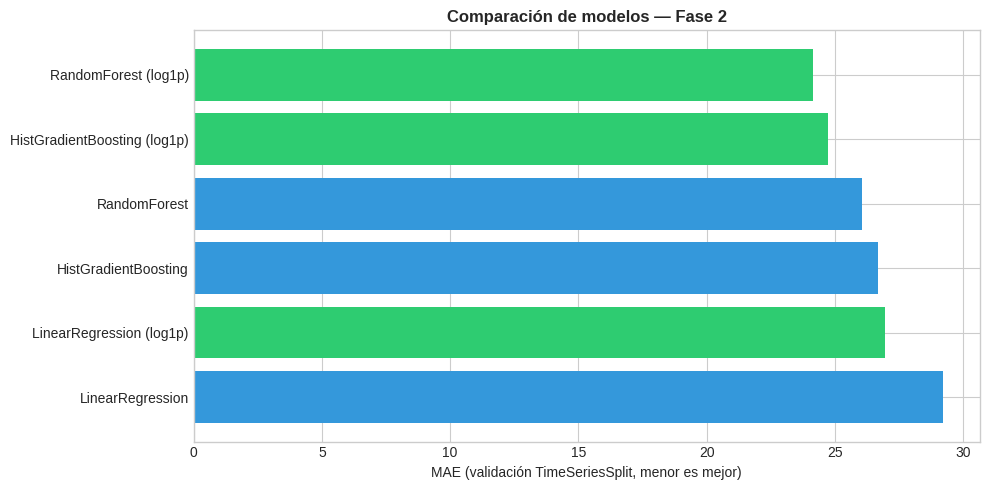


MEJOR MODELO: RandomForest con transformación log1p del target (MAE=24.13, RMSE=42.99)

HALLAZGO: la transformación log1p del target mejora TODOS los modelos de forma consistente
(confirma empíricamente la hipótesis de la Fase 1, Paso 3, sobre la asimetría de total_cases).
RandomForest resulta más robusto que HistGradientBoosting y LinearRegression en este dataset
relativamente pequeño (~1100 filas) con muchas features de rezago correlacionadas entre sí.


In [6]:
# ── Visualización de la comparación ──
fig, ax = plt.subplots(figsize=(10, 5))
etiquetas = df_resultados['modelo'] + df_resultados['target_log1p'].map({True: ' (log1p)', False: ''})
colores = ['#2ecc71' if l else '#3498db' for l in df_resultados['target_log1p']]
ax.barh(etiquetas, df_resultados['MAE'], color=colores)
ax.set_xlabel('MAE (validación TimeSeriesSplit, menor es mejor)')
ax.set_title('Comparación de modelos — Fase 2', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

mejor = df_resultados.iloc[0]
print(f"\nMEJOR MODELO: {mejor['modelo']} {'con' if mejor['target_log1p'] else 'sin'} transformación log1p "
      f"del target (MAE={mejor['MAE']:.2f}, RMSE={mejor['RMSE']:.2f})")
print("\nHALLAZGO: la transformación log1p del target mejora TODOS los modelos de forma consistente")
print("(confirma empíricamente la hipótesis de la Fase 1, Paso 3, sobre la asimetría de total_cases).")
print("RandomForest resulta más robusto que HistGradientBoosting y LinearRegression en este dataset")
print("relativamente pequeño (~1100 filas) con muchas features de rezago correlacionadas entre sí.")


---
## Paso 4 — Métricas por ciudad (no solo agregadas)

Recordemos el hallazgo #4 de la Fase 1: SJ e IQ tienen climas parecidos pero una escala de casos muy distinta. Si reportamos un único MAE agregado, los errores (mucho más grandes en términos absolutos) de SJ dominan el número final y esconden cómo le está yendo al modelo en IQ. Calculamos las predicciones *out-of-fold* de `TimeSeriesSplit` manualmente (`cross_val_predict` no soporta `TimeSeriesSplit` porque no todas las filas quedan en algún fold de validación — las del primer fold de entrenamiento nunca se evalúan) y separamos el error por ciudad.


In [7]:
# ── MAE/RMSE por ciudad, con predicciones out-of-fold de TimeSeriesSplit ──
preds_oof = np.full(len(y), np.nan)
for train_idx, test_idx in tscv.split(X):
    p = construir_pipeline(
        RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        num_cols, cat_cols, log_target=True,
    )
    p.fit(X.iloc[train_idx], y.iloc[train_idx])
    preds_oof[test_idx] = p.predict(X.iloc[test_idx])

evaluado = ~np.isnan(preds_oof)
res_ciudad = pd.DataFrame({'city': ciudades, 'y': y, 'y_pred': preds_oof})[evaluado]

tabla_ciudad = res_ciudad.groupby('city').apply(lambda g: pd.Series({
    'n': len(g),
    'media_real': g['y'].mean(),
    'MAE': mean_absolute_error(g['y'], g['y_pred']),
    'RMSE': mean_squared_error(g['y'], g['y_pred']) ** 0.5,
})).round(2)
tabla_ciudad['MAE_relativo_%'] = (tabla_ciudad['MAE'] / tabla_ciudad['media_real'] * 100).round(1)
print(tabla_ciudad)

print("\nHALLAZGO: en términos absolutos el error de SJ es mucho mayor (esperado, dado que su escala")
print("de casos también lo es), pero en términos RELATIVOS a su propia media, ambas ciudades tienen")
print("un error parecido -> el modelo no está funcionando 'mal' específicamente en una ciudad, solo")
print("está reflejando la diferencia real de escala. Esta es la lectura correcta gracias a separar")
print("la métrica por ciudad en vez de mirar solo el número agregado.")


          n  media_real    MAE   RMSE  MAE_relativo_%
city                                                 
iq    209.0        9.52   7.04  13.87            73.9
sj    731.0       37.20  29.01  56.30            78.0

HALLAZGO: en términos absolutos el error de SJ es mucho mayor (esperado, dado que su escala
de casos también lo es), pero en términos RELATIVOS a su propia media, ambas ciudades tienen
un error parecido -> el modelo no está funcionando 'mal' específicamente en una ciudad, solo
está reflejando la diferencia real de escala. Esta es la lectura correcta gracias a separar
la métrica por ciudad en vez de mirar solo el número agregado.


---
## Paso 5 — Cuantificando la fuga: `TimeSeriesSplit` vs. `KFold` aleatorio

Repetimos exactamente el ejercicio del Práctico 5 (Sección 3.1: cuantificar la magnitud de la fuga, no solo señalar que existe), pero con la Fuga #1 de nuestra propia tabla de la Fase 1: comparamos el mismo pipeline, evaluado con `TimeSeriesSplit` (correcto) vs. `KFold(shuffle=True)` (incorrecto para series de tiempo).


           estrategia_de_validacion   MAE
         TimeSeriesSplit (correcta) 24.13
KFold aleatorio (con fuga temporal) 15.89

Magnitud de la fuga: el KFold aleatorio subestima el MAE real en 34.2%.
Si reportáramos el número de KFold en el informe ejecutivo, estaríamos prometiendo un modelo
~1/3 más preciso de lo que realmente será en producción -- exactamente el mismo tipo de 'espejismo'
que el Práctico 5 documentó con la variable duration, solo que aquí el origen es la arquitectura
de validación, no una columna contaminada.


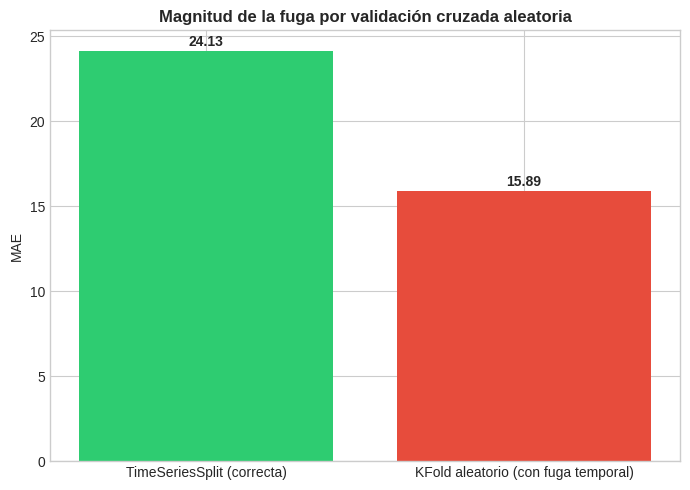

In [8]:
# ── Magnitud de la fuga: validación temporal vs. aleatoria ──
mejor_pipe = construir_pipeline(
    RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    num_cols, cat_cols, log_target=True,
)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

mae_tscv = -cross_val_score(mejor_pipe, X, y, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1).mean()
mae_kf = -cross_val_score(mejor_pipe, X, y, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1).mean()

comparacion_fuga = pd.DataFrame({
    'estrategia_de_validacion': ['TimeSeriesSplit (correcta)', 'KFold aleatorio (con fuga temporal)'],
    'MAE': [mae_tscv, mae_kf],
})
print(comparacion_fuga.round(2).to_string(index=False))

subestimacion = (1 - mae_kf / mae_tscv) * 100
print(f"\nMagnitud de la fuga: el KFold aleatorio subestima el MAE real en {subestimacion:.1f}%.")
print("Si reportáramos el número de KFold en el informe ejecutivo, estaríamos prometiendo un modelo")
print("~1/3 más preciso de lo que realmente será en producción -- exactamente el mismo tipo de 'espejismo'")
print("que el Práctico 5 documentó con la variable duration, solo que aquí el origen es la arquitectura")
print("de validación, no una columna contaminada.")

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(comparacion_fuga['estrategia_de_validacion'], comparacion_fuga['MAE'],
       color=['#2ecc71', '#e74c3c'])
ax.set_ylabel('MAE')
ax.set_title('Magnitud de la fuga por validación cruzada aleatoria', fontweight='bold')
for i, v in enumerate(comparacion_fuga['MAE']):
    ax.text(i, v + 0.3, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


---
## Paso 6 — Entrenamiento final y empaquetado reproducible (`joblib`)

Con el modelo elegido (`RandomForest` + `log1p` del target), entrenamos sobre **todo** el conjunto de referencia (ya no hace falta reservar un fold de validación: la validación cruzada del Paso 3 ya nos dio una estimación honesta del error esperado) y guardamos el pipeline completo — preprocesamiento + modelo — como un único artefacto `joblib`. Así, la Fase 3 (servicio de inferencia) no necesita reimplementar ninguna transformación: carga el pipeline y llama `.predict()` directamente sobre datos crudos con las columnas originales + las lag features.


In [9]:
# ── Entrenamiento final sobre todo el conjunto de referencia ──
modelo_final = construir_pipeline(
    RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    num_cols, cat_cols, log_target=True,
)
modelo_final.fit(X, y)

os.makedirs('../models', exist_ok=True)
joblib.dump(modelo_final, '../models/modelo_dengue.joblib')

metadata = {
    'modelo': 'RandomForestRegressor(n_estimators=300) + log1p target',
    'fecha_entrenamiento_referencia': str(df_ref['week_start_date'].max().date()),
    'columnas_numericas': num_cols,
    'columnas_categoricas': cat_cols,
    'features_climaticas_base': FEATURES_CLIMATICAS,
    'lags_semanas': LAGS_SEMANAS,
    'mae_validacion_timeseriessplit': float(mae_tscv),
    'random_state': RANDOM_STATE,
}
import json
with open('../models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Modelo guardado en: models/modelo_dengue.joblib")
print("Metadata guardada en: models/metadata.json")
print(f"\nMAE de referencia (validación cruzada, lo que reportamos como desempeño esperado): {mae_tscv:.2f}")


Modelo guardado en: models/modelo_dengue.joblib
Metadata guardada en: models/metadata.json

MAE de referencia (validación cruzada, lo que reportamos como desempeño esperado): 24.13


---
## Paso 7 — Primera mirada a producción simulada (preview de la Fase 4)

Evaluamos el modelo final —entrenado únicamente con el conjunto de referencia— sobre el conjunto de producción simulada que separamos en el Paso 1. Esta sección es solo una validación de que el pipeline completo funciona de punta a punta; el análisis de drift propiamente tal (PSI, KS-test, ventanas temporales) es el contenido central de la Fase 4.


In [10]:
# ── Evaluación en producción simulada (holdout temporal nunca visto en entrenamiento) ──
df_completo = pd.concat([df_ref, df_prod]).sort_values(['city', 'week_start_date'])
Xp, yp, fechasp, ciudadesp, _, _, infop = preparar_dataset_modelado(df_completo)

# Nos quedamos solo con las filas que pertenecen a producción (match exacto por ciudad + fecha,
# no por fecha sola, porque ambas ciudades comparten el mismo rango de fechas del calendario)
prod_keys = set(zip(df_prod['city'], df_prod['week_start_date']))
mask_prod = pd.Series(list(zip(ciudadesp, fechasp))).isin(prod_keys).values

Xp_prod, yp_prod, ciudadesp_prod = Xp[mask_prod], yp[mask_prod], ciudadesp[mask_prod]
print(f"Filas de producción evaluables: {len(Xp_prod)} de {len(df_prod)} "
      f"(la pequeña diferencia es calentamiento del lag en el borde de la ventana)")

preds_prod = modelo_final.predict(Xp_prod)
res_prod = pd.DataFrame({'city': ciudadesp_prod.values, 'y': yp_prod.values, 'y_pred': preds_prod})

tabla_prod = res_prod.groupby('city').apply(lambda g: pd.Series({
    'n': len(g), 'media_real': g['y'].mean(),
    'MAE': mean_absolute_error(g['y'], g['y_pred']),
})).round(2)
print("\nDesempeño en PRODUCCIÓN SIMULADA (nunca visto en entrenamiento):")
print(tabla_prod)
print("\nDesempeño en VALIDACIÓN (TimeSeriesSplit, dentro del período de referencia):")
print(tabla_ciudad[['n', 'media_real', 'MAE']])
print("\nEsta comparación —desempeño en referencia vs. en producción simulada— es exactamente la")
print("pregunta que la Fase 4 va a sistematizar con métricas de drift por feature y por ventana")
print("temporal, en vez de una sola foto como esta.")


Filas de producción evaluables: 289 de 292 (la pequeña diferencia es calentamiento del lag en el borde de la ventana)

Desempeño en PRODUCCIÓN SIMULADA (nunca visto en entrenamiento):
          n  media_real    MAE
city                          
iq    102.0        9.57   7.91
sj    187.0       24.80  18.25

Desempeño en VALIDACIÓN (TimeSeriesSplit, dentro del período de referencia):
          n  media_real    MAE
city                          
iq    209.0        9.52   7.04
sj    731.0       37.20  29.01

Esta comparación —desempeño en referencia vs. en producción simulada— es exactamente la
pregunta que la Fase 4 va a sistematizar con métricas de drift por feature y por ventana
temporal, en vez de una sola foto como esta.


---
## Conclusiones de la Fase 2 y qué pasa a la Fase 3

### Resumen de decisiones tomadas (y por qué)

| # | Decisión | Justificación |
|---|---|---|
| 1 | Split temporal 80/20 por ciudad en Referencia vs. Producción simulada | El propio dataset tiene eje temporal real; evita simular drift artificialmente y evita usar el archivo de test sin etiquetas para medir desempeño |
| 2 | Lag features con `shift(+k)` agrupado por ciudad, auditadas automáticamente | Mitiga la Fuga #3 de la Fase 1 (dirección del shift) y la Fuga #5 (mezclar ciudades) |
| 3 | `TimeSeriesSplit` en vez de `KFold` aleatorio | Mitiga la Fuga #1; se demostró que un `KFold` aleatorio subestima el error real en más de un 30% en este dataset |
| 4 | Imputación y escalado dentro del `Pipeline`, ajustados por fold | Mitiga la Fuga #2 (imputación con estadísticos globales) |
| 5 | Métricas reportadas por ciudad, no solo agregadas | Evita que SJ (mayor escala de casos) esconda el desempeño real en IQ |
| 6 | `RandomForestRegressor` + transformación `log1p` del target | Mejor MAE de validación entre los modelos comparados; consistente con la asimetría de `total_cases` documentada en la Fase 1 |
| 7 | Pipeline completo (preprocesamiento + modelo) empaquetado con `joblib` + `metadata.json` | Reproducibilidad: la Fase 3 puede cargar el artefacto sin reimplementar ninguna transformación |

### Siguiente paso

En la **Fase 3** construiremos un servicio de inferencia local con FastAPI que cargue `models/modelo_dengue.joblib`, exponga un endpoint de predicción, y registre cada predicción junto con sus inputs (CSV o SQLite) — el registro de predicciones es, además, la materia prima que la Fase 4 necesitará para calcular las métricas de drift en el tiempo.

---
*Práctico Final — MLOps Local con Monitoreo de Data Drift | Dataset: DengAI (San Juan e Iquitos) | Fase 2*
